# Setup Environment

In [1]:
# Import libraries

# Standard libraries
from pathlib import Path

# Data manipulation and visualization libraries
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

## Models
import sklearn 
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.feature_extraction import DictVectorizer
from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, roc_curve, auc as sk_auc 

# Gradient Boosting Libraries
from xgboost import XGBClassifier
from catboost import CatBoostClassifier 

# Tuning
import optuna

# Saving and loading models
import joblib

print(f"NumPy version: {np.__version__}")
print(f"pandas version: {pd.__version__}")
print(f"matplotlib version: {matplotlib.__version__}")
print(f"seaborn version: {sns.__version__}")
print(f"Scikit-Learn version: {sklearn.__version__}")

NumPy version: 2.4.5
pandas version: 3.0.3
matplotlib version: 3.11.0
seaborn version: 0.13.2
Scikit-Learn version: 1.9.0


In [2]:
# Create image and model directories if they don't exist

eda_plots_dir             = Path("plots/EDA")
model_selection_plots_dir = Path("plots/Model_Selection")
features_plots_dir        = Path("plots/Features")
models_dir                = Path("models")

eda_plots_dir.mkdir(parents=True, exist_ok=True)
model_selection_plots_dir.mkdir(parents=True, exist_ok=True)
features_plots_dir.mkdir(parents=True, exist_ok=True)
models_dir.mkdir(parents=True, exist_ok=True)

# Data Collection and Preprocessing

In [3]:
# Load the dataset

# make the data directory if it doesn't exist
if not Path('data').exists():
    Path('data').mkdir()

# download the dataset if it doesn't exist, else load it from the local file
if not Path('data/credit_scoring.csv').is_file():
    data_url = 'https://raw.githubusercontent.com/alexeygrigorev/mlbookcamp-code/master/chapter-06-trees/CreditScoring.csv'
    df = pd.read_csv(data_url, encoding='utf-8')
    df.to_csv('data/credit_scoring.csv', index=False)
else:
    df = pd.read_csv('data/credit_scoring.csv', encoding='utf-8')
 
df.info()
df.head()

<class 'pandas.DataFrame'>
RangeIndex: 4455 entries, 0 to 4454
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   Status     4455 non-null   int64
 1   Seniority  4455 non-null   int64
 2   Home       4455 non-null   int64
 3   Time       4455 non-null   int64
 4   Age        4455 non-null   int64
 5   Marital    4455 non-null   int64
 6   Records    4455 non-null   int64
 7   Job        4455 non-null   int64
 8   Expenses   4455 non-null   int64
 9   Income     4455 non-null   int64
 10  Assets     4455 non-null   int64
 11  Debt       4455 non-null   int64
 12  Amount     4455 non-null   int64
 13  Price      4455 non-null   int64
dtypes: int64(14)
memory usage: 487.4 KB


,Status,Seniority,Home,Time,Age,Marital,Records,Job,Expenses,Income,Assets,Debt,Amount,Price
0,1,9,1,60,30,2,1,3,73,129,0,0,800,846
1,1,17,1,60,58,3,1,1,48,131,0,0,1000,1658
2,2,10,2,36,46,2,2,3,90,200,3000,0,2000,2985
3,1,0,1,60,24,1,1,1,63,182,2500,0,900,1325
4,1,0,1,36,26,1,1,1,46,107,0,0,310,910


In [4]:
# Data Cleaning: Convert column names to lowercase, Replace placeholder values

# Convert all column names to lowercase
df.columns = df.columns.str.lower()

# Replace placeholder value 99999999 with NaN
for c in ['income', 'assets', 'debt']:
    df[c] = df[c].replace(to_replace=99999999, value=np.nan)


In [5]:
# Data Cleaning: Convert categorical variables to their corresponding string values using mapping dictionaries
home_values = {
    1: 'rent',
    2: 'owner',
    3: 'private',
    4: 'ignore',
    5: 'parents',
    6: 'other',
    0: 'unk'
}

marital_values = {
    1: 'single',
    2: 'married',
    3: 'widow',
    4: 'separated',
    5: 'divorced',
    0: 'unk'
}

records_values = {
    1: 'no',
    2: 'yes',
    0: 'unk'
}

job_values = {
    1: 'fixed',
    2: 'partime',
    3: 'freelance',
    4: 'others',
    0: 'unk'
}

status_values = {
    1: 'ok',
    2: 'default',
    0: 'unk'
}

df.home    = df.home.map(home_values)
df.marital = df.marital.map(marital_values)
df.records = df.records.map(records_values)
df.job     = df.job.map(job_values)
df.status  = df.status.map(status_values)
df = df[df.status != 'unk'].reset_index(drop=True)  # Remove rows with unknown status values and reset the index

# Check the data types of the columns and display summary statistics for numerical columns
df.describe().round()

,seniority,time,age,expenses,income,assets,debt,amount,price
count,4454.0,4454.0,4454.0,4454.0,4420.0,4407.0,4436.0,4454.0,4454.0
mean,8.0,46.0,37.0,56.0,131.0,5404.0,343.0,1039.0,1463.0
std,8.0,15.0,11.0,20.0,86.0,11574.0,1246.0,475.0,628.0
min,0.0,6.0,18.0,35.0,0.0,0.0,0.0,100.0,105.0
25%,2.0,36.0,28.0,35.0,80.0,0.0,0.0,700.0,1117.0
50%,5.0,48.0,36.0,51.0,120.0,3000.0,0.0,1000.0,1400.0
75%,12.0,60.0,45.0,72.0,165.0,6000.0,0.0,1300.0,1692.0
max,48.0,72.0,68.0,180.0,959.0,300000.0,30000.0,5000.0,11140.0


# Exploratory Data Analysis (EDA)

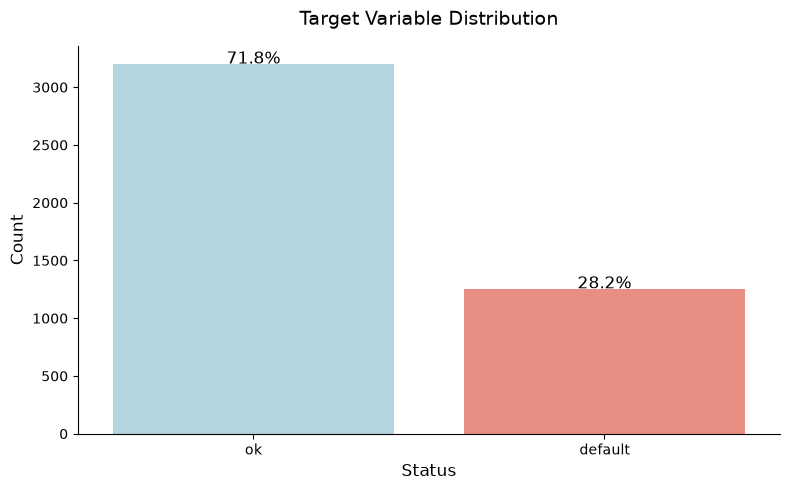

In [6]:
# Plot the vertical bar chart of the target variable from df

# Calculate the percentage of each status value and create a new DataFrame for plotting
df_status = df['status'].value_counts(normalize=True).mul(100).rename('percent').reset_index()
df_status.columns = ['Status', 'percent']
df_status['count'] = df['status'].value_counts().values

# Plot the vertical bar chart
plt.figure(figsize=(8, 5))
ax = sns.barplot(x='Status', y='count', data=df_status, palette=['lightblue', 'salmon'], hue='Status', legend=False)

# Annotate the bars with the percentage values
for i, p in enumerate(ax.patches):
    height = p.get_height()
    ax.text(p.get_x() + p.get_width() / 2., height + 5, 
            f'{df_status["percent"][i]:.1f}%', ha="center", fontsize=12)

plt.title('Target Variable Distribution', fontsize=14, pad=15)
plt.ylabel('Count', fontsize=12)
plt.xlabel('Status', fontsize=12)
sns.despine()
plt.tight_layout()
plt.savefig(eda_plots_dir/ '01_target_variable_distribution.png', dpi=300)
plt.show()

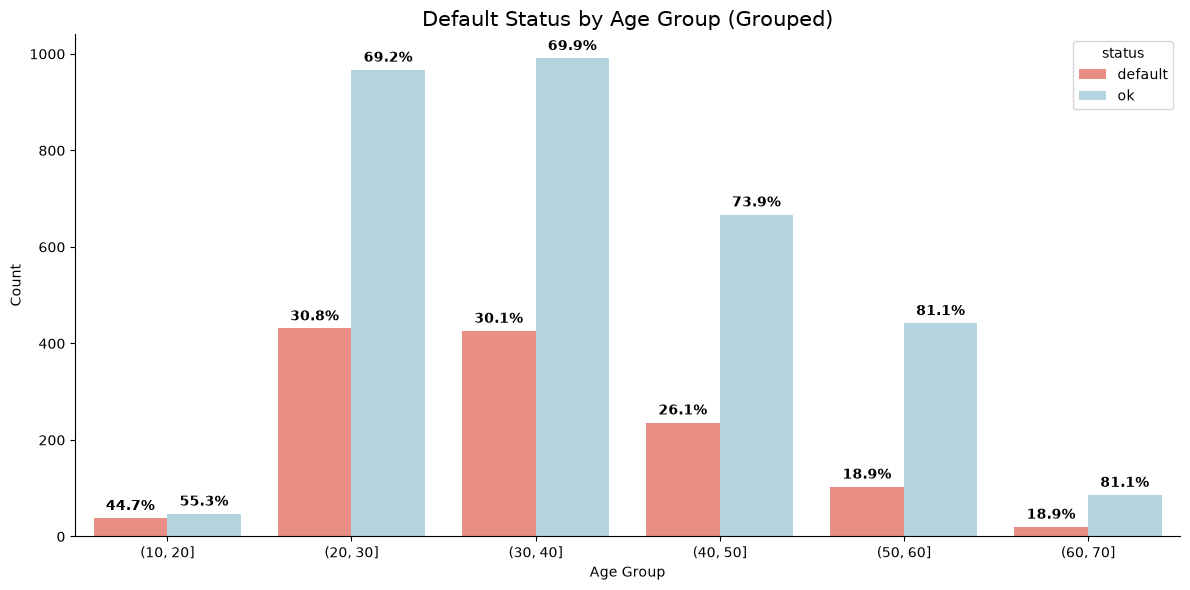

In [7]:
# Age Distribution Analysis: Create age groups and plot the distribution of default status by age group

# 1. Use a copy of the dataframe for analysis to protect original data
df_analysis = df.copy()

# 2. Create age groups
bins = range(10, 80, 10)
df_analysis['age_group'] = pd.cut(df_analysis['age'], bins=bins)

# 3. Use crosstab to get counts and normalize for percentages
# normalize='index' calculates the percentage within each age group
ct = pd.crosstab(df_analysis['age_group'], df_analysis['status'])
ct_pct = pd.crosstab(df_analysis['age_group'], df_analysis['status'], normalize='index') * 100

# 4. Melt the dataframe for Seaborn plotting (converts wide to long format)
df_plot = ct.reset_index().melt(id_vars='age_group', var_name='status', value_name='count')

# 5. Create the Plot
plt.figure(figsize=(12, 6))
ax = sns.barplot(
    x='age_group', 
    y='count', 
    hue='status', 
    data=df_plot, 
    palette={'default': 'salmon', 'ok': 'lightblue'}
)

# 6. Add percentage labels on top of each bar
# We iterate through the bars and fetch the percentage from our normalized crosstab
for i, p in enumerate(ax.patches):
    height = p.get_height()
    if height > 0:
        # Get age group and status from the bar position and order
        age_idx = i % len(ct)
        status_col = 'default' if i < len(ct) else 'ok'
        pct = ct_pct.loc[ct_pct.index[age_idx], status_col]
        
        ax.text(
            p.get_x() + p.get_width() / 2, 
            height + 10, 
            f'{pct:.1f}%', 
            ha='center', va='bottom', fontsize=10, fontweight='bold'
        )

plt.title('Default Status by Age Group (Grouped)', fontsize=15)
plt.ylabel('Count')
plt.xlabel('Age Group')
sns.despine()
plt.tight_layout()
plt.savefig(eda_plots_dir/ '02_default_status_by_age_group.png', dpi=300)
plt.show()

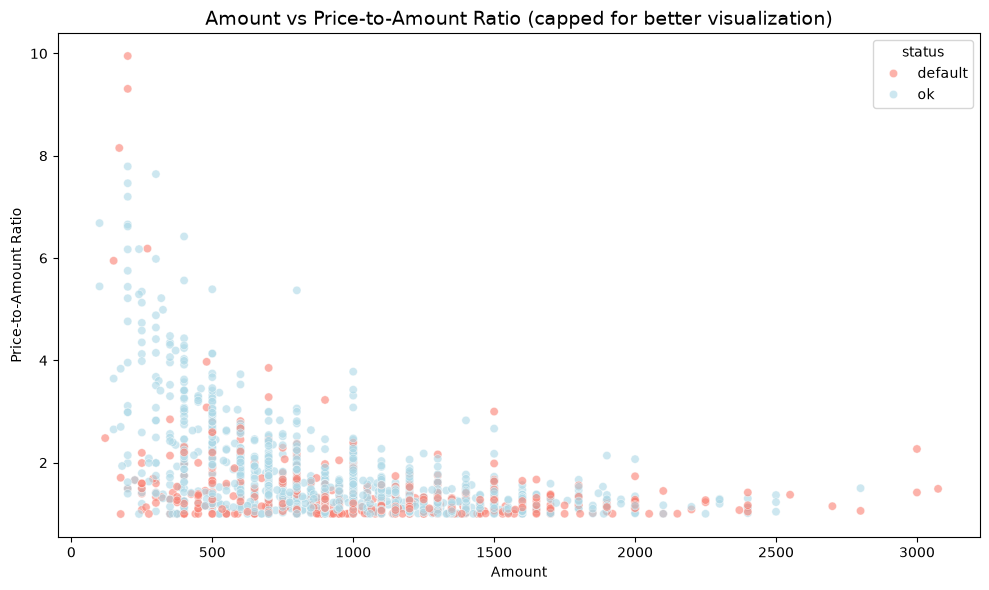

In [8]:
# Multivariate Analysis: Scatter plot of amount vs price colored by status

# Create a new DataFrame for analysis to avoid modifying the original df
df_analysis = df.copy()
df_analysis['diff'] = df_analysis['price'] - df_analysis['amount']
df_analysis['ratio'] = df_analysis['price'] / (df_analysis['amount'] + 1)

# filter out extreme values for better visualization
df_analysis = df_analysis[(df_analysis['amount'] < 3500) & (df_analysis['diff'].abs() < 5000) & (df_analysis['ratio'] < 10)]
max_samples = 2000
df_analysis_sample = df_analysis.sample(n=max_samples, random_state=42)

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_analysis_sample, x='amount', y='ratio', hue='status', palette= {'ok': 'lightblue', 'default': 'salmon'}, alpha=0.6)
plt.title('Amount vs Price-to-Amount Ratio (capped for better visualization)', fontsize=14)
plt.xlabel('Amount')
plt.ylabel('Price-to-Amount Ratio')
plt.tight_layout()
plt.savefig(eda_plots_dir/ '03_amount_vs_price_ratio.png', dpi=300)
plt.show()

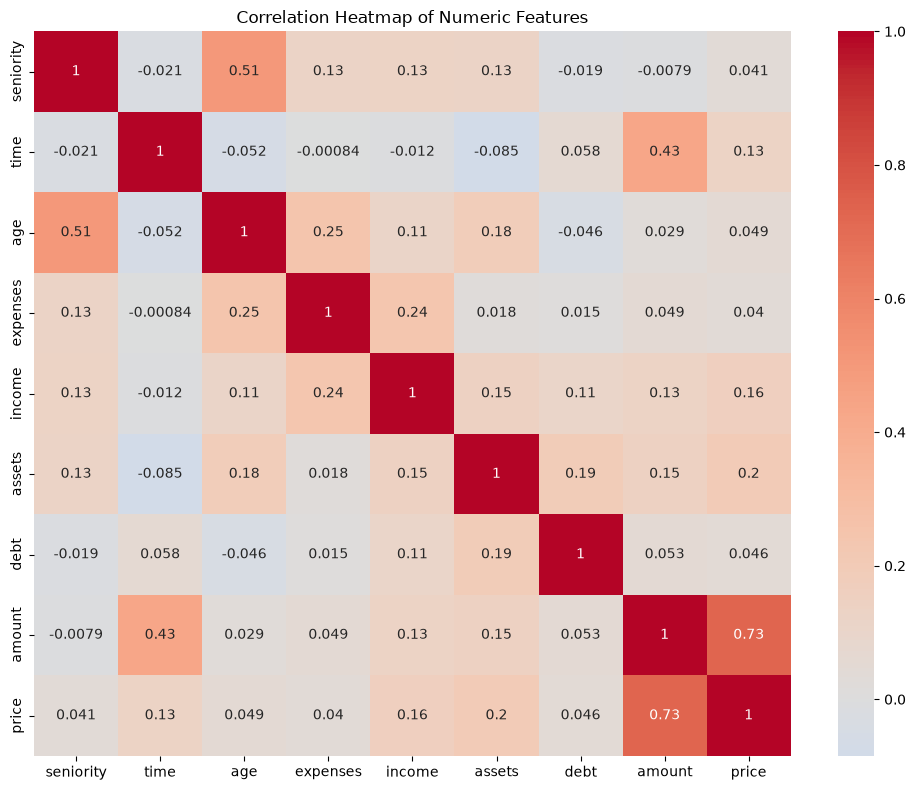

In [9]:
# Correlation Heatmap
df_analysis = df.copy()
# keep only numeric columns for correlation analysis
df_analysis = df_analysis.select_dtypes(include=[np.number])

plt.figure(figsize=(10, 8))
sns.heatmap(df_analysis.corr(), annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Heatmap of Numeric Features')
plt.tight_layout()
plt.savefig(eda_plots_dir/ '04_correlation_heatmap.png', dpi=300)
plt.show()

# Data Splitting & Feature Engineering

In [10]:
# Data splitting

# Split the dataset into training, validation, and test sets with a 60-20-20 split
df_full_train, df_test = train_test_split(df, test_size=0.2, random_state=11)
df_train, df_val = train_test_split(df_full_train, test_size=0.25, random_state=11)

# Reset the index of the dataframes to ensure that the indices are sequential and start from 0
df_train = df_train.reset_index(drop=True)
df_val   = df_val.reset_index(drop=True)
df_test  = df_test.reset_index(drop=True)

# Change the target variable to a binary indicator
# If the status is 'default', we set it to 1, otherwise we set it to 0, then convert it to a numpy array
y_train = (df_train.status == 'default').astype('int').values
y_val   = (df_val.status == 'default').astype('int').values
y_test  = (df_test.status == 'default').astype('int').values

# Remove the target variable 'status'
del df_train['status']
del df_val['status']
del df_test['status']

df_train

,seniority,home,time,age,marital,records,job,expenses,income,assets,debt,amount,price
0,10,owner,36,36,married,no,freelance,75,0.0,10000.0,0.0,1000,1400
1,6,parents,48,32,single,yes,fixed,35,85.0,0.0,0.0,1100,1330
2,1,parents,48,40,married,no,fixed,75,121.0,0.0,0.0,1320,1600
3,1,parents,48,23,single,no,partime,35,72.0,0.0,0.0,1078,1079
4,5,owner,36,46,married,no,freelance,60,100.0,4000.0,0.0,1100,1897
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2667,18,private,36,45,married,no,fixed,45,220.0,20000.0,0.0,800,1600
2668,7,private,60,29,married,no,fixed,60,51.0,3500.0,500.0,1000,1290
2669,1,parents,24,19,single,no,fixed,35,28.0,0.0,0.0,400,600
2670,15,owner,48,43,married,no,freelance,60,100.0,18000.0,0.0,2500,2976


In [ ]:
# Feature Engineering 

def feature_engineering(df):
    df = df.copy()
    
    # 1. Age Binning
    bins = [0, 20, 30, 40, 50, 60, 100]
    if 'age' in df.columns:
        df['age_group'] = pd.cut(df['age'], bins=bins).astype(str)
        df.drop(columns=['age'], inplace=True)
    
    # 2. Price and amount (differences and ratios)
    df['diff'] = df['price'] - df['amount']
    df['ratio'] = df['price'] / (df['amount'] + 1)
    
    # 3. Affordability metrics
    df['debt_income_ratio'] = df['debt'] / (df['income'] + 1)
    df['assets_amount_ratio'] = df['assets'] / (df['amount'] + 1)
    # Cap extreme values to reduce noise in tree models
    for col in ['debt_income_ratio', 'assets_amount_ratio']:
        upper_limit = df[col].quantile(0.99)
        df[col] = df[col].clip(upper=upper_limit)
    
    return df

# Apply feature engineering to the training, validation, and test datasets
df_train_eng = feature_engineering(df_train)
df_val_eng   = feature_engineering(df_val)
df_test_eng  = feature_engineering(df_test)

# Convert the dataframes to dictionaries and then vectorize them using DictVectorizer
dv = DictVectorizer(sparse=True)

train_dicts = df_train_eng.fillna(0).to_dict(orient='records')
val_dicts   = df_val_eng.fillna(0).to_dict(orient='records')
test_dicts  = df_test_eng.fillna(0).to_dict(orient='records')

X_train = dv.fit_transform(train_dicts)
X_val   = dv.transform(val_dicts)
X_test  = dv.transform(test_dicts)


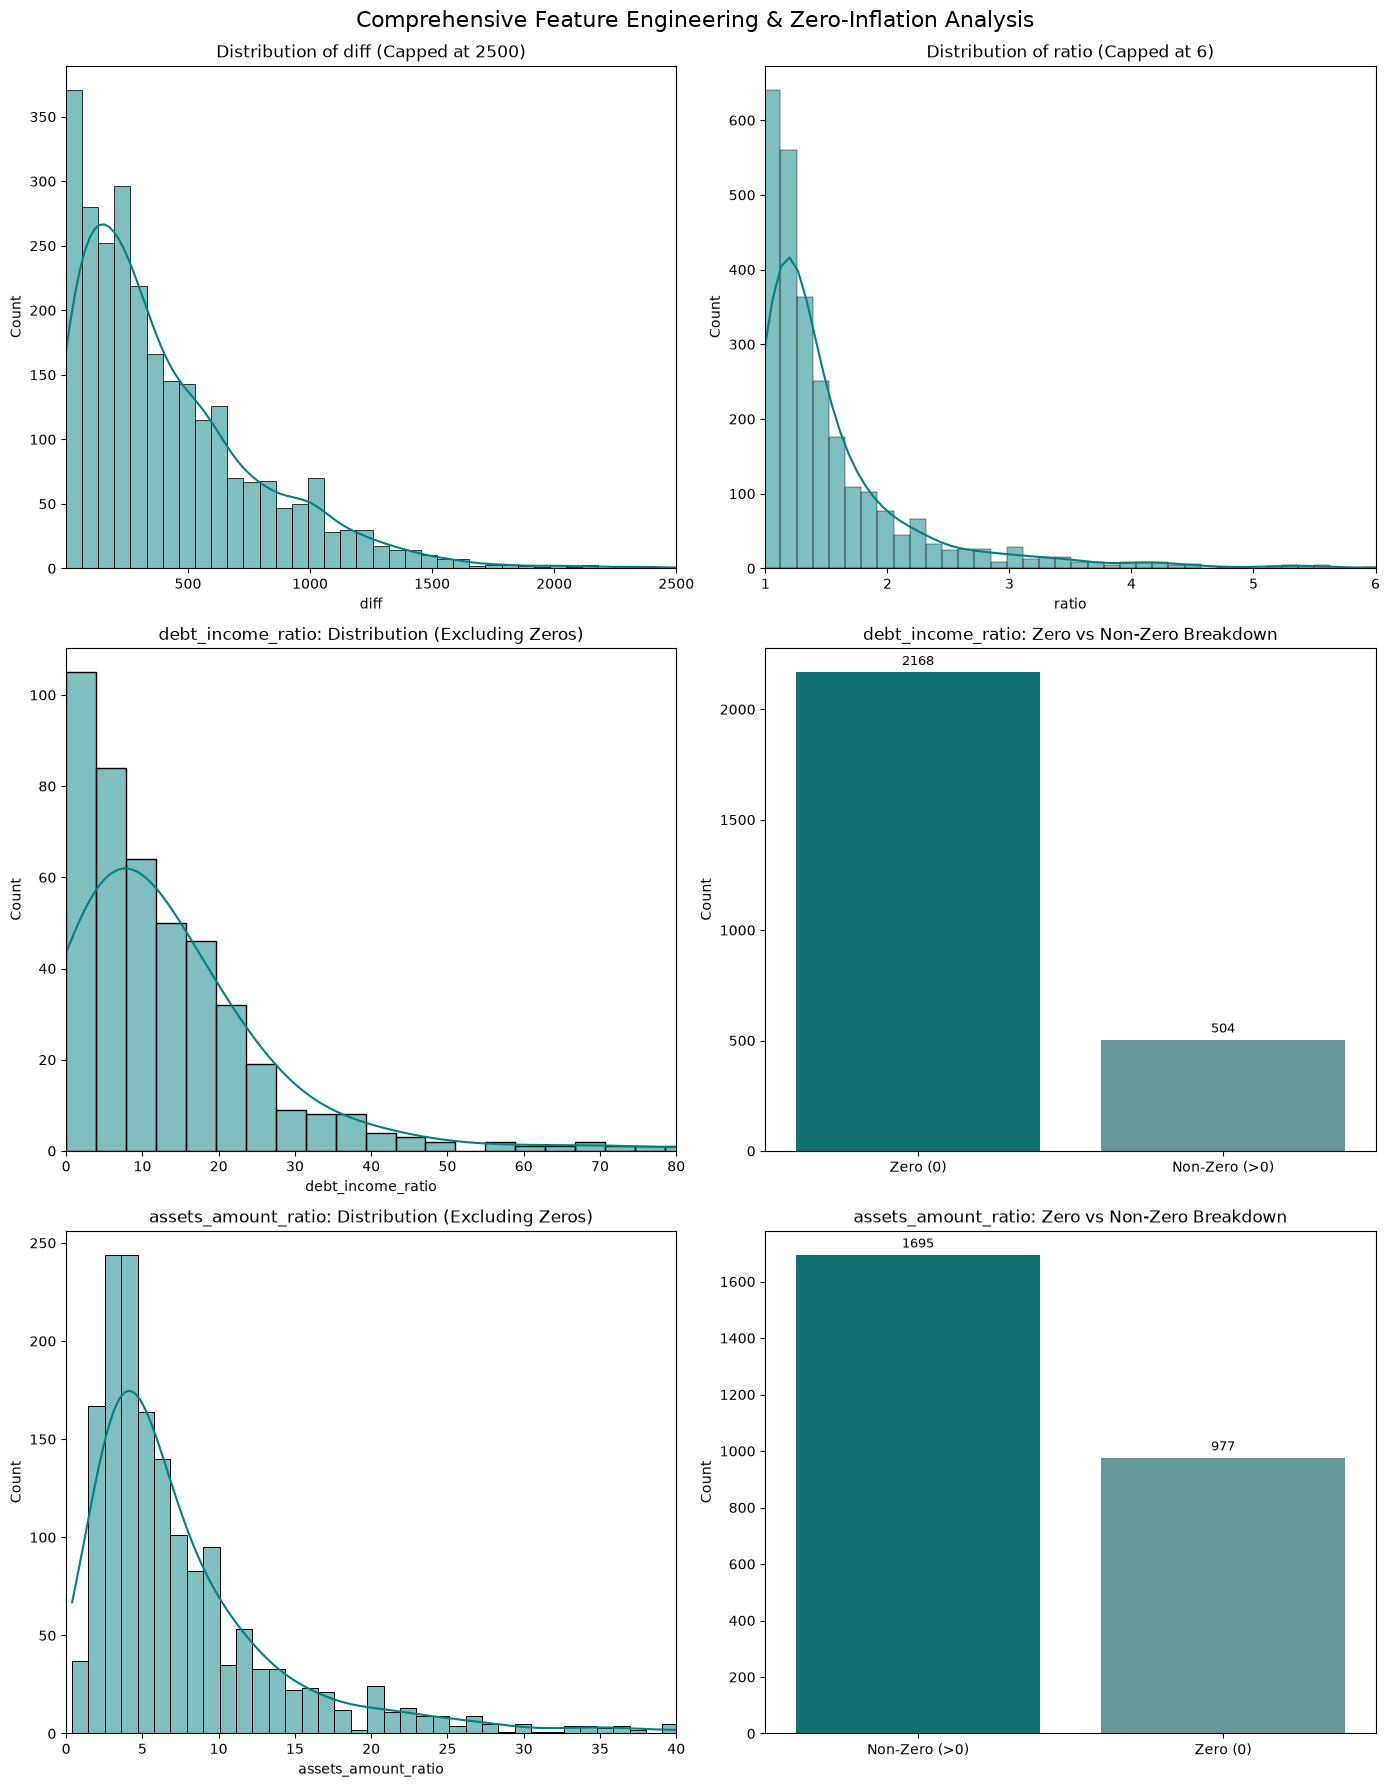

In [26]:
# Visualization of Engineered Features

# 3 rows and 2 columns of subplots
fig, axes = plt.subplots(3, 2, figsize=(14, 18))

# --- Row 0: Diff & Ratio ---
sns.histplot(df_train_eng['diff'], kde=True, ax=axes[0, 0], color='teal')
axes[0, 0].set_title('Distribution of diff (Capped at 2500)', fontsize=12)
axes[0, 0].set_xlabel('diff')
axes[0, 0].set_xlim(1, 2500)

sns.histplot(df_train_eng['ratio'], kde=True, ax=axes[0, 1], color='teal')
axes[0, 1].set_title('Distribution of ratio (Capped at 6)', fontsize=12)
axes[0, 1].set_xlabel('ratio')
axes[0, 1].set_xlim(1, 6)

# --- Rows 1 & 2: Debt-Income Ratio & Assets-Amount Ratio (Handled via Loop) ---
ratio_configs = [
    {'feature': 'debt_income_ratio', 'row': 1, 'xlim': 80},
    {'feature': 'assets_amount_ratio', 'row': 2, 'xlim': 40}
]

for config in ratio_configs:
    feat = config['feature']
    r_idx = config['row']
    
    # Left：Zoomed distribution plot for non-zero values
    data_nz = df_train_eng[df_train_eng[feat] > 0][feat]
    sns.histplot(data_nz, kde=True, ax=axes[r_idx, 0], color='teal')
    axes[r_idx, 0].set_title(f'{feat}: Distribution (Excluding Zeros)', fontsize=12)
    axes[r_idx, 0].set_xlabel(feat)
    axes[r_idx, 0].set_xlim(0, config['xlim'])

    # Right：Zero vs Non-Zero Bar plot 
    # with hue and legend=False to prevent future warnings
    is_zero = (df_train_eng[feat] == 0)
    counts = is_zero.map({True: 'Zero (0)', False: 'Non-Zero (>0)'}).value_counts()
    
    sns.barplot(
        x=counts.index, y=counts.values, 
        hue=counts.index, palette=['teal', 'cadetblue'], 
        ax=axes[r_idx, 1], legend=False
    )
    axes[r_idx, 1].set_title(f'{feat}: Zero vs Non-Zero Breakdown', fontsize=12)
    axes[r_idx, 1].set_ylabel('Count')
    axes[r_idx, 1].set_xlabel('')
    
    # annotate the bars with counts
    for p in axes[r_idx, 1].patches:
        axes[r_idx, 1].annotate(
            f'{int(p.get_height())}', 
            (p.get_x() + p.get_width() / 2., p.get_height()), 
            ha='center', va='bottom', fontsize=9, xytext=(0, 3), 
            textcoords='offset points'
        )

plt.suptitle('Comprehensive Feature Engineering & Zero-Inflation Analysis', fontsize=16, y=0.99)
plt.tight_layout()
plt.savefig(eda_plots_dir / '05_comprehensive_features_analysis.png', dpi=300)
plt.show()

# Model - Decision Trees